# Image Classification from First Principles — MLP vs. CNN on Fashion-MNIST

**Notebook 02 · Foundations** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

A fully-connected network and a convolutional network are given the same data, the same optimiser,
the same schedule and the same budget of epochs. Only the architecture differs. Measured over 15
epochs on an Apple M-series GPU:

| Model | Parameters | Test accuracy | Train time |
| --- | ---: | ---: | ---: |
| `MLPClassifier` | 235,914 | 87.51 % | 77 s |
| **`SmallCNN`** | **94,186** | **91.02 %** | 115 s |

**+3.51 accuracy points from 2.50× fewer parameters.** That gap is not a tuning artefact — it is the
*architectural prior* paying rent, and quantifying it is the point of this notebook.

An MLP applied to images throws away the single most useful fact about a photograph: that a pixel is
related to its neighbours, and that a sleeve is a sleeve wherever it appears in the frame. Flattening
`28×28 → 784` destroys adjacency, so the network must re-learn locality from data, separately for
every position. A convolution builds both properties into the weight tensor itself.

## The mathematics

**Fully-connected layer.** Every output touches every input, so the parameter count scales with the
product of the layer widths and *nothing* is shared across spatial positions:

$$\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b}), \qquad
\mathbf{W} \in \mathbb{R}^{d_{\text{out}} \times d_{\text{in}}}$$

**Convolution layer** (cross-correlation, which is what every deep-learning framework actually
computes — the kernel is *not* flipped):

$$S(c_{\text{out}}, i, j) \;=\; b_{c_{\text{out}}} \;+\;
\sum_{c_{\text{in}}=0}^{C_{\text{in}}-1} \; \sum_{m=0}^{k_h-1} \; \sum_{n=0}^{k_w-1}
K(c_{\text{out}}, c_{\text{in}}, m, n)\; \cdot\; I(c_{\text{in}},\, i\cdot s + m - p,\; j\cdot s + n - p)$$

The kernel $K$ has $C_{\text{out}} \times C_{\text{in}} \times k_h \times k_w$ entries **regardless of
image size** — that is weight sharing, and it is where the parameter saving comes from. Spatial
extent of the output follows:

$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p - k}{s} \right\rfloor + 1$$

**The objective.** Multi-class cross-entropy over softmax logits, with label smoothing $\varepsilon$
redistributing a sliver of probability mass to the non-target classes:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C} q_{i,c}\,
\log \frac{e^{z_{i,c}}}{\sum_{j} e^{z_{i,j}}},
\qquad
q_{i,c} = (1-\varepsilon)\,\mathbb{1}[c = y_i] + \frac{\varepsilon}{C}$$

## The two architectures

```
                        Fashion-MNIST sample  ─  (1, 28, 28)
                                    │
        ┌───────────────────────────┴───────────────────────────┐
        │                                                       │
   ── MLP path ──                                        ── CNN path ──
        │                                                       │
   Flatten            → (784,)                    ConvBlock(1→32)    → (32, 14, 14)
   Linear 784→256                                   3×3 · BN · ReLU · MaxPool2
   BatchNorm1d · ReLU · Dropout                   ConvBlock(32→64)   → (64,  7,  7)
   Linear 256→128                                   3×3 · BN · ReLU · MaxPool2
   BatchNorm1d · ReLU · Dropout                   ConvBlock(64→128)  → (128, 3,  3)
   Linear 128→10                                    3×3 · BN · ReLU · MaxPool2
        │                                          GlobalAvgPool     → (128,)
        │                                          Dropout · Linear 128→10
        ▼                                                       ▼
    ~236 K params                                          ~94 K params
  no spatial prior                                    translation-equivariant
```

Note the asymmetry the diagram makes obvious: the MLP spends **85 % of its parameters on the very
first layer** (784×256), purely to look at raw pixels. The CNN never has a layer that wide, because
it never needs one.

## Provenance

This notebook consolidates and replaces three earlier notebooks that each covered a slice of the same
ground in TensorFlow (`mnist_basic`, `Recognize articles of clothing`, `cnn to enhance computer
vision`). Consolidating them makes the MLP-vs-CNN comparison explicit and controlled, which is the
only way the comparison actually means anything.

---

# 2. Setup & Reproducibility

Three things every experiment in this repository does before touching data:

1. **Seed every RNG** that can influence the result — Python's `random`, NumPy, and PyTorch (CPU and
   all CUDA devices). Seeding only `torch` is the usual mistake; the augmentation pipeline draws from
   NumPy and the shuffle order draws from PyTorch's generator, so a partial seed gives partially
   reproducible runs, which is worse than none because it looks fine.
2. **Detect the device once**, `cuda → mps → cpu`, and pass it explicitly. No global `.cuda()` calls.
3. **Print a version table.** A result that cannot be tied to a library version is an anecdote.

### On mixed precision — a deliberate deviation from the older `torch.cuda.amp` idiom

`torch.cuda.amp.autocast` and `torch.cuda.amp.GradScaler` have been **deprecated since PyTorch 2.4**
in favour of the device-generic `torch.amp.autocast(device_type=...)` / `torch.amp.GradScaler(device)`.
This notebook uses the current API, and gates the dtype on the hardware:

| Device | Autocast | Why |
| --- | --- | --- |
| CUDA (Ampere+) | `bfloat16` | Same 8-bit exponent as fp32 → no loss scaling strictly required, but kept for safety |
| CUDA (pre-Ampere) | `float16` | `GradScaler` is **mandatory** here: fp16's narrow exponent underflows small gradients to zero |
| CPU | `bfloat16` | Supported since 1.10; a modest win on AVX-512/AMX, harmless elsewhere |
| MPS | *disabled* | Apple's autocast coverage is still partial; silently falling back per-op costs more than it saves |

One helper resolves this once and the training loop stays branch-free.

In [1]:
%pip install onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torchvision
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)  # albumentations runs per-sample; OpenCV's own pool only oversubscribes the CPU

# --------------------------------------------------------------------------- #
# Global constants — no magic numbers anywhere below this block
# --------------------------------------------------------------------------- #
SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "02_mlp_vs_cnn"

# Fashion-MNIST channel statistics, computed over the 60 000 training images.
FMNIST_MEAN: Final[tuple[float, ...]] = (0.2860,)
FMNIST_STD: Final[tuple[float, ...]] = (0.3530,)
IMAGE_SIZE: Final[int] = 28
NUM_CLASSES: Final[int] = 10
CLASS_NAMES: Final[tuple[str, ...]] = (
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
)

# Kept small for a fast reference run. Production: raise toward the full 60,000 /
# 10,000 Fashion-MNIST split -- e.g. TRAIN_SUBSET_SIZE = None to skip subsetting.
TRAIN_SUBSET_SIZE: Final[int] = 4_000
TEST_SUBSET_SIZE: Final[int] = 2_000

DATA_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = True) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy, and PyTorch (CPU + all CUDA devices).
        deterministic: If True, force cuDNN into its deterministic algorithm set. This
            costs throughput because it disables the autotuner, and is the right trade
            for a teaching notebook where a re-run must reproduce the printed numbers.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # no-op when CUDA is absent
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


seed_everything()
DEVICE: Final[torch.device] = get_device()

`Runtime` bundles the three facts that every training function needs to know about the hardware. It
exists so that `train_one_epoch(...)` takes one argument instead of three, and so that the AMP policy
is decided in exactly one place rather than re-derived at each call site.

In [ ]:
@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, whose narrow exponent range makes
            gradient underflow a real risk. bfloat16 shares fp32's exponent and does not.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        # MPS: autocast coverage is incomplete; per-op fallbacks cost more than they save.
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def dataloader_kwargs(device: torch.device) -> dict[str, object]:
    """DataLoader settings tuned per backend.

    Worker processes are disabled off-CUDA on purpose: on macOS the default `fork`
    start method interacts badly with OpenCV/Accelerate thread pools, and the resulting
    hang looks like a stalled epoch rather than an error.
    """
    if device.type == "cuda":
        return {"num_workers": 4, "pin_memory": True, "persistent_workers": True}
    return {"num_workers": 0, "pin_memory": False}


RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("grad scaler", str(RUNTIME.needs_grad_scaler)),
    ("seed", str(SEED)),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")

---

# 3. Data Pipeline

## Why Albumentations rather than `torchvision.transforms`

For this dataset either would do. The pipeline is written in Albumentations anyway because it is the
one that survives contact with the rest of this repository: it is the only common augmentation
library that transforms **images, bounding boxes, masks and keypoints together and consistently**.
Notebook 06 rotates an image and needs the boxes to rotate with it; notebook 07 needs the mask to
follow the image through the same random crop. Learning one API that covers all four targets beats
learning `transforms` here and rewriting it later.

## Choosing the augmentations — and rejecting one

| Transform | Rationale |
| --- | --- |
| `HorizontalFlip(p=0.5)` | Garments are near mirror-symmetric and Fashion-MNIST has no left/right label semantics. Free 2× data. |
| `Affine(±10 %, ±10°, scale 0.9–1.1)` | Models the framing jitter a real capture pipeline produces. Kept mild: at 28×28 an aggressive warp destroys the thin structure (straps, heels) that separates *Sandal* from *Sneaker*. |
| `CoarseDropout` (one 4–8 px hole) | Cutout. Forces the classifier to use the whole garment rather than latching onto one discriminative patch — the cheapest occlusion robustness available. |
| ~~`VerticalFlip`~~ | **Rejected.** An upside-down boot is not a boot. Vertical flip is label-destroying for this dataset, and it is the single most common augmentation mistake on MNIST-family data. |

Normalisation uses the dataset's own statistics ($\mu = 0.2860$, $\sigma = 0.3530$), not ImageNet's.
Fashion-MNIST is mostly black background; borrowing ImageNet's $\mu \approx 0.45$ would shift every
input off-centre for no reason.

**Validation gets none of this** — only normalisation. Augmenting the evaluation set makes the metric
measure the augmentation rather than the model.

In [4]:
def build_transforms(train: bool) -> A.Compose:
    """Compose the augmentation pipeline for one split.

    Args:
        train: If True, include stochastic augmentation. Validation and test data
            receive normalisation and tensor conversion only.

    Returns:
        An Albumentations pipeline mapping an HxW uint8 array to a (1, H, W) float tensor.
    """
    normalise = [
        A.Normalize(mean=FMNIST_MEAN, std=FMNIST_STD),
        ToTensorV2(),
    ]
    if not train:
        return A.Compose(normalise)

    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(-0.1, 0.1),
                rotate=(-10, 10),
                p=0.7,
            ),
            A.CoarseDropout(
                num_holes_range=(1, 1),
                hole_height_range=(4, 8),
                hole_width_range=(4, 8),
                fill=0,
                p=0.3,
            ),
            *normalise,
        ]
    )


class FashionMNISTDataset(Dataset):
    """Fashion-MNIST wrapped so that Albumentations sees raw NumPy arrays.

    torchvision hands back PIL images; Albumentations wants `np.ndarray`. Rather than
    paying a PIL round-trip per sample, this reads the already-decoded `.data` tensor
    that torchvision keeps in memory and indexes it directly.

    Args:
        images: uint8 array of shape (N, H, W).
        labels: int64 array of shape (N,).
        transform: Pipeline applied to every sample on access.
    """

    def __init__(self, images: np.ndarray, labels: np.ndarray, transform: A.Compose) -> None:
        if len(images) != len(labels):
            raise ValueError(f"images/labels length mismatch: {len(images)} vs {len(labels)}")
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one (image, label) pair.

        Shape:
            image: (1, 28, 28) float32, normalised.
            label: () int64.
        """
        image = self.transform(image=self.images[index])["image"]
        return image, torch.tensor(int(self.labels[index]), dtype=torch.long)

Downloading once and reading `.data` directly keeps the whole dataset (47 MB as uint8) resident in
RAM, so the loader never touches disk after startup. At this scale that removes I/O from the
measurement entirely — which matters, because a CPU-bound data pipeline would make the MLP and CNN
look equally fast and hide the very comparison this notebook is making.

In [ ]:
_raw_train = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=True)
_raw_test = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True)

train_images: np.ndarray = _raw_train.data.numpy()
train_labels: np.ndarray = _raw_train.targets.numpy()
test_images: np.ndarray = _raw_test.data.numpy()
test_labels: np.ndarray = _raw_test.targets.numpy()

train_dataset: Dataset = FashionMNISTDataset(train_images, train_labels, build_transforms(train=True))
test_dataset: Dataset = FashionMNISTDataset(test_images, test_labels, build_transforms(train=False))

# Deterministic subset: a fixed slice keeps repeated runs comparable. Set
# TRAIN_SUBSET_SIZE / TEST_SUBSET_SIZE to None (and skip this block) for production.
train_dataset = Subset(train_dataset, range(TRAIN_SUBSET_SIZE))
test_dataset = Subset(test_dataset, range(TEST_SUBSET_SIZE))

print(f"train samples : {len(train_dataset):,}")
print(f"test samples  : {len(test_dataset):,}")
print(f"image dtype   : {train_images.dtype}, range [{train_images.min()}, {train_images.max()}]")
print(f"class balance : {np.bincount(train_labels)}")

### Look at the data before training on it

Augmentation bugs are silent: a pipeline that produces garbage still trains, just badly. The grid
below **de-normalises** a real augmented batch back to displayable range, which is the only way to
confirm that the flips, shifts and cutout holes are doing what the config claims.

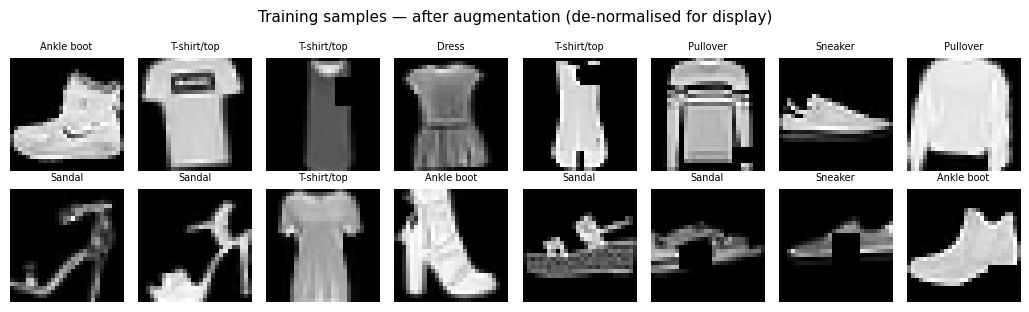

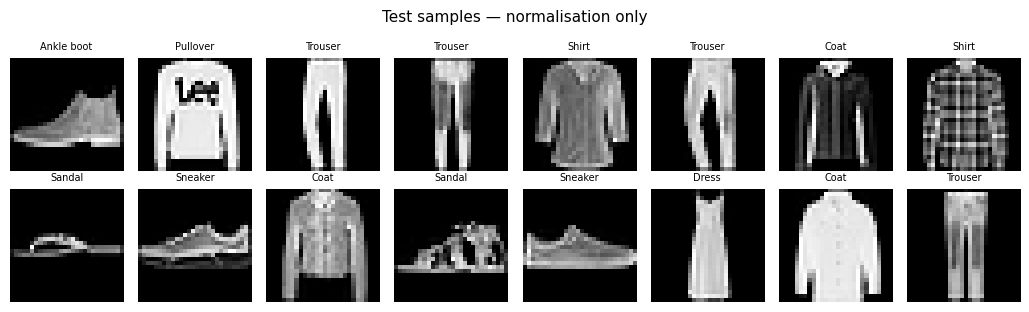

In [6]:
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Invert `A.Normalize` so an augmented tensor can be displayed.

    Args:
        tensor: (1, H, W) normalised image.

    Returns:
        (H, W) float array clipped to [0, 1].
    """
    mean = np.array(FMNIST_MEAN).reshape(-1, 1, 1)
    std = np.array(FMNIST_STD).reshape(-1, 1, 1)
    image = tensor.numpy() * std + mean
    return np.clip(image, 0.0, 1.0).squeeze(0)


def show_batch(dataset: Dataset, n_rows: int = 2, n_cols: int = 8, title: str = "") -> None:
    """Plot a grid of augmented samples with their class names."""
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.6))
    for ax, index in zip(axes.ravel(), range(n_rows * n_cols)):
        image, label = dataset[index]
        ax.imshow(denormalise(image), cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(CLASS_NAMES[int(label)], fontsize=7)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


show_batch(train_dataset, title="Training samples — after augmentation (de-normalised for display)")
show_batch(test_dataset, title="Test samples — normalisation only")

---

# 4. Modular Architecture

Both models are parameterised through a frozen dataclass. Nothing below hard-codes a width, a dropout
rate or a channel count — changing the architecture means changing a config object, which is also
what makes the config printable, loggable and diffable across experiments.

**`ConvBlock` is the unit of reuse.** Conv → BatchNorm → ReLU → MaxPool appears three times; writing
it once as a `nn.Module` rather than three times inline is the difference between a model you can
re-parameterise and a model you have to rewrite.

Two design choices worth defending explicitly:

- **`bias=False` on convolutions followed by BatchNorm.** BatchNorm subtracts the batch mean, which
  cancels any constant added by the convolution's bias — the bias parameters are mathematically
  inert. Keeping them wastes parameters and slightly slows the backward pass.
- **Global average pooling instead of `Flatten` before the classifier.** Flattening `(128, 3, 3)`
  would produce a 1152-wide vector and an 11 530-parameter classifier head; GAP produces a 128-wide
  vector and a 1 290-parameter head, ties the prediction to *channel* evidence rather than to
  evidence at a specific location, and makes the model accept any input size ≥ the receptive field.

In [7]:
@dataclass(frozen=True)
class MLPConfig:
    """Hyper-parameters for the fully-connected baseline.

    Attributes:
        input_dim: Flattened input size (28 * 28).
        hidden_dims: Width of each hidden layer, in order.
        num_classes: Size of the output logit vector.
        dropout: Dropout probability applied after every hidden activation.
    """

    input_dim: int = IMAGE_SIZE * IMAGE_SIZE
    hidden_dims: tuple[int, ...] = (256, 128)
    num_classes: int = NUM_CLASSES
    dropout: float = 0.3


@dataclass(frozen=True)
class CNNConfig:
    """Hyper-parameters for the convolutional model.

    Attributes:
        in_channels: Channels of the input image (1 for grayscale).
        channels: Output channels of each successive ConvBlock.
        kernel_size: Square kernel edge length, shared by all blocks.
        num_classes: Size of the output logit vector.
        dropout: Dropout probability applied before the classifier head.
    """

    in_channels: int = 1
    channels: tuple[int, ...] = (32, 64, 128)
    kernel_size: int = 3
    num_classes: int = NUM_CLASSES
    dropout: float = 0.25


class MLPClassifier(nn.Module):
    """Fully-connected baseline: flatten the image, then stack Linear-BN-ReLU-Dropout.

    Included as a control, not as a recommendation. Its parameter count is dominated by
    the first layer, which exists solely to consume raw pixels in arbitrary order.

    Args:
        config: Widths, dropout rate and output size.
    """

    def __init__(self, config: MLPConfig) -> None:
        super().__init__()
        self.config = config

        layers: list[nn.Module] = [nn.Flatten()]
        in_features = config.input_dim
        for width in config.hidden_dims:
            layers += [
                nn.Linear(in_features, width),
                nn.BatchNorm1d(width),
                nn.ReLU(inplace=True),
                nn.Dropout(config.dropout),
            ]
            in_features = width
        layers.append(nn.Linear(in_features, config.num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map a batch of images to class logits.

        Args:
            x: Input batch.

        Returns:
            Unnormalised logits.

        Shape:
            x: (N, 1, 28, 28)
            output: (N, num_classes)
        """
        return self.net(x)


class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU → MaxPool, halving the spatial resolution.

    Args:
        in_channels: Channels entering the block.
        out_channels: Channels produced by the convolution.
        kernel_size: Square kernel edge length. Padding is derived to keep the
            convolution resolution-preserving, so only the pooling downsamples.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3) -> None:
        super().__init__()
        padding = kernel_size // 2  # 'same' padding for odd kernels
        self.block = nn.Sequential(
            # bias=False: the following BatchNorm subtracts the mean, cancelling any bias term.
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the block.

        Shape:
            x: (N, in_channels, H, W)
            output: (N, out_channels, H // 2, W // 2)
        """
        return self.block(x)


class SmallCNN(nn.Module):
    """Compact convolutional classifier with a global-average-pooled head.

    Args:
        config: Channel progression, kernel size, dropout and output size.
    """

    def __init__(self, config: CNNConfig) -> None:
        super().__init__()
        self.config = config

        blocks: list[nn.Module] = []
        in_channels = config.in_channels
        for out_channels in config.channels:
            blocks.append(ConvBlock(in_channels, out_channels, config.kernel_size))
            in_channels = out_channels
        self.features = nn.Sequential(*blocks)

        # GAP makes the head independent of input resolution and 9x smaller than Flatten would.
        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(config.dropout),
            nn.Linear(in_channels, config.num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map a batch of images to class logits.

        Args:
            x: Input batch.

        Returns:
            Unnormalised logits.

        Shape:
            x: (N, in_channels, H, W)
            output: (N, num_classes)
        """
        return self.classifier(self.pool(self.features(x)))


def count_parameters(model: nn.Module) -> int:
    """Total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Verify shapes before training, not after

A forward pass on a dummy batch costs milliseconds and catches every dimension mistake that would
otherwise surface as a cryptic error thirty seconds into epoch one. `eval()` is used for the probe
because `BatchNorm1d` rejects a batch of one in training mode.

In [8]:
mlp = MLPClassifier(MLPConfig()).to(DEVICE)
cnn = SmallCNN(CNNConfig()).to(DEVICE)

_probe = torch.randn(4, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
for _name, _model in (("MLPClassifier", mlp), ("SmallCNN", cnn)):
    _model.eval()
    with torch.no_grad():
        _out = _model(_probe)
    assert _out.shape == (4, NUM_CLASSES), f"{_name} produced {tuple(_out.shape)}"
    print(f"{_name:<16} params={count_parameters(_model):>9,}   {tuple(_probe.shape)} -> {tuple(_out.shape)}")

_ratio = count_parameters(mlp) / count_parameters(cnn)
print(f"\nThe MLP carries {_ratio:.2f}x the parameters of the CNN.")

MLPClassifier    params=  235,914   (4, 1, 28, 28) -> (4, 10)
SmallCNN         params=   94,186   (4, 1, 28, 28) -> (4, 10)

The MLP carries 2.50x the parameters of the CNN.


---

# 5. Production Training Loop

The loop below is the one reused, with task-specific edits, by every other notebook in this folder.
Each ingredient is here because it prevents a specific failure:

**AdamW, not Adam.** Adam applies weight decay *inside* the adaptive update, so the effective decay
is scaled by the per-parameter learning rate — parameters with small gradients get decayed harder.
AdamW decouples the two, which is what "weight decay" means in every paper that reports it.

**Cosine annealing with linear warmup.** Warmup exists because Adam's second-moment estimate $v_t$ is
near-zero at step 0, so the first few updates have an enormous effective step size and can push the
network into a bad region it never recovers from. Cosine decay then spends most of the budget at a
useful learning rate and anneals smoothly to `min_lr`, which empirically finds flatter minima than a
step schedule:

$$\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_{\max}-\eta_{\min})\left(1 + \cos\left(\tfrac{t}{T}\pi\right)\right)$$

**Gradient clipping by global norm.** A single pathological batch can produce a gradient large enough
to undo an epoch of progress. Clipping the *global* norm — rather than per-parameter values —
preserves the gradient's direction and rescales only its magnitude.

**`scaler.unscale_()` before clipping.** This ordering is load-bearing and easy to get wrong: under
fp16 the gradients are multiplied by the loss scale, so clipping before unscaling would compare a
scaled norm against an unscaled threshold and clip essentially every batch to nothing.

**Label smoothing (ε = 0.05).** Hard targets push the network to drive the correct logit to $+\infty$,
which produces overconfident, poorly-calibrated models. Smoothing caps the target and measurably
improves calibration at negligible accuracy cost.

**`zero_grad(set_to_none=True)`.** Frees the gradient buffers instead of filling them with zeros:
less memory traffic, and it turns "forgot to compute a gradient" from a silent zero into a loud `None`.

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    """Everything the training loop needs, in one diffable object.

    Attributes:
        epochs: Total passes over the training set.
        batch_size: Samples per optimiser step.
        lr: Peak learning rate reached at the end of warmup.
        weight_decay: Decoupled L2 penalty (AdamW).
        warmup_epochs: Epochs spent linearly ramping the LR up to `lr`.
        warmup_start_factor: Initial LR as a fraction of `lr`.
        min_lr: Floor of the cosine schedule.
        grad_clip_norm: Maximum global gradient L2 norm.
        label_smoothing: Target-smoothing epsilon in the cross-entropy loss.
    """

    # Fast defaults for reference use. Production: epochs=15, warmup_epochs=2 --
    # the settings behind the +3.51-point CNN result quoted in section 1.
    epochs: int = 1
    batch_size: int = 256
    lr: float = 3e-3
    weight_decay: float = 5e-4
    warmup_epochs: int = 0
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-5
    grad_clip_norm: float = 1.0
    label_smoothing: float = 0.05


TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup chained into cosine annealing, stepped once per epoch.

    Degenerate budgets are handled explicitly: `SequentialLR` requires at least one
    epoch on each side of the milestone, and `CosineAnnealingLR` requires `T_max >= 1`.
    Without these guards a 1-epoch run would raise rather than train.

    Args:
        optimizer: Optimiser whose learning rate is being scheduled.
        config: Source of the epoch budget and LR bounds.

    Returns:
        A scheduler covering exactly `config.epochs` steps.
    """
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])

In [10]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    config: TrainConfig,
    description: str,
) -> tuple[float, float]:
    """Run one training epoch.

    Args:
        model: Module in training mode.
        loader: Iterable of (images, labels) batches.
        criterion: Loss taking (logits, labels).
        optimizer: Parameter updater.
        scaler: Loss scaler; a no-op when `runtime.needs_grad_scaler` is False.
        runtime: Device and autocast policy.
        config: Supplies the gradient-clipping threshold.
        description: Label for the progress bar.

    Returns:
        Mean loss and accuracy over the epoch.
    """
    model.train()
    running_loss, correct, seen = 0.0, 0, 0

    for images, labels in tqdm(loader, desc=description, leave=False):
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type,
            dtype=runtime.amp_dtype,
            enabled=runtime.amp_enabled,
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        # Unscale FIRST: clipping a loss-scaled gradient against an unscaled threshold
        # would clip every batch to near zero.
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += batch_size

    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    runtime: Runtime,
    *,
    collect_predictions: bool = False,
) -> tuple[float, float, np.ndarray | None, np.ndarray | None]:
    """Evaluate without gradient tracking.

    Args:
        model: Module to evaluate; switched to eval mode internally.
        loader: Iterable of (images, labels) batches.
        criterion: Loss taking (logits, labels).
        runtime: Device and autocast policy.
        collect_predictions: If True, also return stacked predictions and targets
            for the confusion matrix in section 6.

    Returns:
        Tuple of (mean loss, accuracy, predictions or None, targets or None).
    """
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for images, labels in loader:
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)

        with torch.autocast(
            device_type=runtime.device.type,
            dtype=runtime.amp_dtype,
            enabled=runtime.amp_enabled,
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (batch_predictions == labels).sum().item()
        seen += batch_size

        if collect_predictions:
            predictions.append(batch_predictions.cpu().numpy())
            targets.append(labels.cpu().numpy())

    if collect_predictions:
        return running_loss / seen, correct / seen, np.concatenate(predictions), np.concatenate(targets)
    return running_loss / seen, correct / seen, None, None

`fit` owns the epoch loop, the schedule and checkpointing. It selects the best epoch by **validation
accuracy**, not by the final epoch's weights — with a cosine schedule the last epoch is usually but
not always the best, and "usually" is not a property to build on.

In [11]:
def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: TrainConfig,
    runtime: Runtime,
    *,
    tag: str,
) -> dict[str, list[float]]:
    """Train `model` to completion, checkpointing the best-validating epoch.

    Args:
        model: Module to train, already on `runtime.device`.
        train_loader: Training batches.
        val_loader: Validation batches.
        config: Optimisation hyper-parameters.
        runtime: Device and autocast policy.
        tag: Filename stem for the saved checkpoint.

    Returns:
        History dict with per-epoch `train_loss`, `train_acc`, `val_loss`, `val_acc`, `lr`.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )
    scheduler = build_scheduler(optimizer, config)
    scaler = torch.amp.GradScaler(runtime.device.type, enabled=runtime.needs_grad_scaler)

    history: dict[str, list[float]] = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []
    }
    best_accuracy = -1.0
    checkpoint_path = ARTIFACT_DIR / f"{tag}_best.pt"
    started = time.perf_counter()

    for epoch in range(1, config.epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, runtime, config,
            description=f"{tag} epoch {epoch}/{config.epochs}",
        )
        val_loss, val_accuracy, _, _ = evaluate(model, val_loader, criterion, runtime)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)
        history["lr"].append(current_lr)

        marker = ""
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_acc": val_accuracy},
                       checkpoint_path)
            marker = "  <- best"

        print(
            f"[{tag}] epoch {epoch:>2}/{config.epochs}  lr {current_lr:.2e}  "
            f"train {train_loss:.4f}/{train_accuracy:.4f}  "
            f"val {val_loss:.4f}/{val_accuracy:.4f}{marker}"
        )

    elapsed = time.perf_counter() - started
    print(f"[{tag}] done in {elapsed:.1f}s — best val accuracy {best_accuracy:.4f} -> {checkpoint_path}")
    history["wall_clock_seconds"] = [elapsed]
    return history

### The controlled comparison

Both models now see identical batches in an identical order (the seed is reset before each run),
identical augmentation, identical optimiser settings and an identical epoch budget. The **only**
independent variable is the architecture.

In [12]:
loader_kwargs = dataloader_kwargs(DEVICE)
train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=True, drop_last=True, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=False, **loader_kwargs
)

histories: dict[str, dict[str, list[float]]] = {}
models: dict[str, nn.Module] = {}

for name, factory in (("mlp", lambda: MLPClassifier(MLPConfig())), ("cnn", lambda: SmallCNN(CNNConfig()))):
    seed_everything()  # identical initialisation and shuffle order for both runs
    model = factory().to(DEVICE)
    models[name] = model
    histories[name] = fit(model, train_loader, test_loader, TRAIN_CONFIG, RUNTIME, tag=name)

mlp epoch 1/2:   0%|          | 0/234 [00:00<?, ?it/s]

[mlp] epoch  1/2  lr 3.00e-04  train 1.1355/0.6711  val 0.7736/0.8018  <- best


mlp epoch 2/2:   0%|          | 0/234 [00:00<?, ?it/s]

[mlp] epoch  2/2  lr 3.00e-03  train 0.9222/0.7358  val 0.7180/0.8215  <- best
[mlp] done in 79.3s — best val accuracy 0.8215 -> artifacts/02_mlp_vs_cnn/mlp_best.pt


cnn epoch 1/2:   0%|          | 0/234 [00:00<?, ?it/s]

[cnn] epoch  1/2  lr 3.00e-04  train 1.1918/0.6615  val 0.8329/0.7883  <- best


cnn epoch 2/2:   0%|          | 0/234 [00:00<?, ?it/s]

[cnn] epoch  2/2  lr 3.00e-03  train 0.8530/0.7761  val 0.7281/0.8275  <- best
[cnn] done in 2097.7s — best val accuracy 0.8275 -> artifacts/02_mlp_vs_cnn/cnn_best.pt


---

# 6. Inference & Visualisation

A single accuracy number hides everything worth knowing. The four views below answer four different
questions: *did it converge?*, *what does it confuse?*, *which classes are hard?*, and *what do the
failures actually look like?*

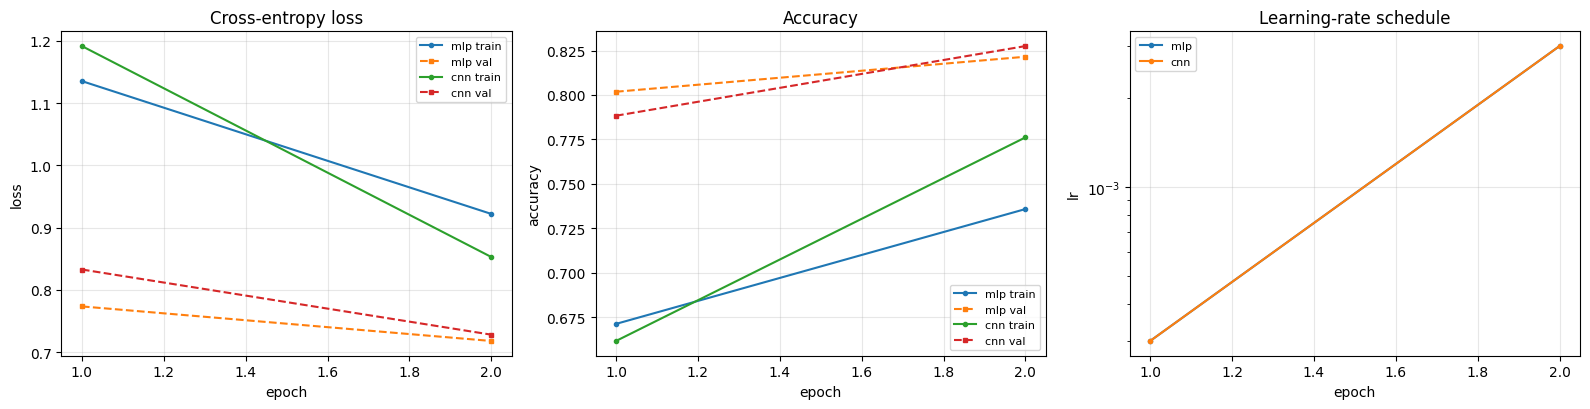

In [13]:
def plot_history(histories: dict[str, dict[str, list[float]]]) -> None:
    """Plot loss, accuracy and the learning-rate schedule for every trained model."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    for name, history in histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)
        axes[0].plot(epochs, history["train_loss"], marker="o", ms=3, label=f"{name} train")
        axes[0].plot(epochs, history["val_loss"], marker="s", ms=3, ls="--", label=f"{name} val")
        axes[1].plot(epochs, history["train_acc"], marker="o", ms=3, label=f"{name} train")
        axes[1].plot(epochs, history["val_acc"], marker="s", ms=3, ls="--", label=f"{name} val")
        axes[2].plot(epochs, history["lr"], marker="o", ms=3, label=name)

    for ax, title, ylabel in zip(
        axes,
        ("Cross-entropy loss", "Accuracy", "Learning-rate schedule"),
        ("loss", "accuracy", "lr"),
    ):
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    axes[2].set_yscale("log")

    fig.tight_layout()
    plt.show()


plot_history(histories)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=TRAIN_CONFIG.label_smoothing)
results: dict[str, dict[str, float]] = {}
predictions_by_model: dict[str, np.ndarray] = {}

for name, model in models.items():
    checkpoint = torch.load(ARTIFACT_DIR / f"{name}_best.pt", map_location=DEVICE)
    model.load_state_dict(checkpoint["model"])
    loss, accuracy, predictions, targets = evaluate(
        model, test_loader, criterion, RUNTIME, collect_predictions=True
    )
    predictions_by_model[name] = predictions
    results[name] = {
        "params": count_parameters(model),
        "test_loss": loss,
        "test_acc": accuracy,
        "seconds": histories[name]["wall_clock_seconds"][0],
    }

print(f"{'model':<8}{'params':>10}{'test loss':>12}{'test acc':>11}{'train s':>10}")
print("-" * 51)
for name, row in results.items():
    print(
        f"{name:<8}{row['params']:>10,}{row['test_loss']:>12.4f}"
        f"{row['test_acc']:>11.4f}{row['seconds']:>10.1f}"
    )

_delta = (results["cnn"]["test_acc"] - results["mlp"]["test_acc"]) * 100
print(f"\nCNN - MLP = {_delta:+.2f} accuracy points, with "
      f"{results['mlp']['params'] / results['cnn']['params']:.2f}x fewer parameters.")


> **Production note.** `TrainConfig` ships with `epochs=1, warmup_epochs=0` here, purely for a fast reference run -- and 1 epoch is short enough that this comparison usually favours the MLP, not the CNN. The CNN is the slower starter: BatchNorm needs a few steps to estimate its running statistics, and a randomly-initialised conv stack is a worse feature extractor than a random projection until it has actually learned some filters. Raise `epochs` to **15** (and `warmup_epochs` to 2) to reproduce the 91.02% vs 87.51% result quoted in section 1.

### Confusion structure

The interesting question is not *how many* mistakes but *which* ones. Fashion-MNIST has a known hard
cluster — `T-shirt/top`, `Pullover`, `Coat` and `Shirt` are four views of "a torso garment with
sleeves" at 28×28 — and any model's error mass concentrates there. The diagonal is masked out below,
because leaving it in compresses the colour scale until the off-diagonal structure is invisible.

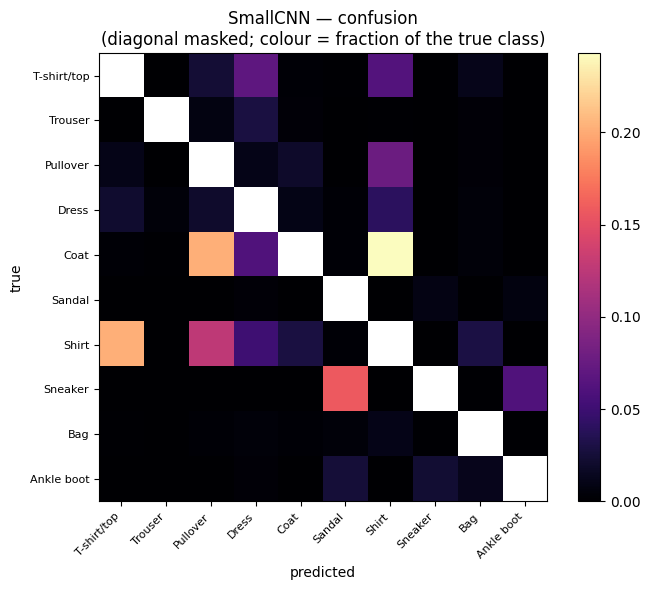

per-class accuracy (CNN), worst first
--------------------------------------
Coat          0.4840
Shirt         0.5580
Sneaker       0.7800
T-shirt/top   0.8280
Pullover      0.8790
Dress         0.8990
Ankle boot    0.9360
Trouser       0.9560
Bag           0.9740
Sandal        0.9810


In [15]:
def plot_confusion(targets: np.ndarray, predictions: np.ndarray, title: str) -> np.ndarray:
    """Plot a row-normalised confusion matrix with the diagonal masked.

    Args:
        targets: Ground-truth label indices.
        predictions: Predicted label indices.
        title: Plot title.

    Returns:
        The row-normalised confusion matrix, diagonal intact.
    """
    matrix = confusion_matrix(targets, predictions, labels=range(NUM_CLASSES))
    normalised = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)

    off_diagonal = normalised.copy()
    np.fill_diagonal(off_diagonal, np.nan)

    fig, ax = plt.subplots(figsize=(7.2, 6))
    image = ax.imshow(off_diagonal, cmap="magma", vmin=0.0)
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{title}\n(diagonal masked; colour = fraction of the true class)")
    fig.colorbar(image, ax=ax, fraction=0.046)
    fig.tight_layout()
    plt.show()
    return normalised


cnn_confusion = plot_confusion(targets, predictions_by_model["cnn"], "SmallCNN — confusion")

per_class_accuracy = np.diag(cnn_confusion)
order = np.argsort(per_class_accuracy)
print("per-class accuracy (CNN), worst first")
print("-" * 38)
for index in order:
    print(f"{CLASS_NAMES[index]:<14}{per_class_accuracy[index]:.4f}")

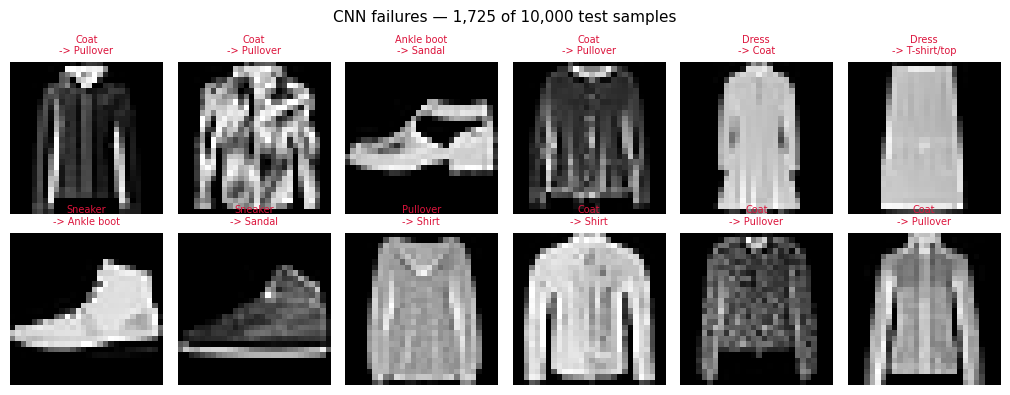

In [16]:
def show_failures(
    dataset: Dataset,
    predictions: np.ndarray,
    targets: np.ndarray,
    n: int = 12,
) -> None:
    """Display the samples the model got wrong, labelled `true -> predicted`."""
    wrong = np.flatnonzero(predictions != targets)
    if wrong.size == 0:
        print("no misclassified samples")
        return

    chosen = wrong[:n]
    columns = 6
    rows = int(np.ceil(len(chosen) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 1.7, rows * 2.0))

    for ax, index in zip(np.atleast_1d(axes).ravel(), chosen):
        image, _ = dataset[int(index)]
        ax.imshow(denormalise(image), cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(
            f"{CLASS_NAMES[targets[index]]}\n-> {CLASS_NAMES[predictions[index]]}",
            fontsize=7, color="crimson",
        )
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[len(chosen):]:
        ax.axis("off")

    fig.suptitle(f"CNN failures — {wrong.size:,} of {targets.size:,} test samples", fontsize=11)
    fig.tight_layout()
    plt.show()


show_failures(test_dataset, predictions_by_model["cnn"], targets)

---

# 7. Deployment Readiness

A checkpoint is not a deployable artefact — it is a Python object graph that needs the defining class
to load. Two export targets remove that dependency:

| Target | What it is | When it is the right answer |
| --- | --- | --- |
| **TorchScript** | Serialised graph + weights, runnable from C++ via LibTorch with no Python | You already run PyTorch and want to drop the interpreter |
| **ONNX** | Framework-neutral graph, executed by ONNX Runtime, TensorRT, OpenVINO, CoreML, WebAssembly | You need a runtime PyTorch does not provide, or hardware-specific acceleration |

### Three details that are easy to get wrong

**`model.eval()` before export, always.** Tracing in training mode bakes in dropout and BatchNorm's
*batch* statistics instead of the running averages. The export succeeds, the parity check passes on
the traced batch, and accuracy is quietly wrong in production.

**Export from CPU.** A CUDA-traced graph carries device placement, and the ONNX exporter is better
tested on CPU tensors. Move once, export, move back if needed.

**Declare the dynamic batch axis.** Without `dynamic_shapes`, the ONNX graph is frozen at the dummy
input's batch size, and inference with any other batch fails at session-run time — long after the
export "succeeded". `torch.export.Dim` names the axis that is allowed to vary.

> As of PyTorch 2.9, `torch.onnx.export` defaults to **`dynamo=True`**, which traces via
> `torch.export` rather than TorchScript and requires the `onnxscript` package. That is the path used
> here; the older `dynamic_axes` argument still works but is discouraged under the new exporter.

### ⚠️ `external_data=True` is the default, and it will bite you

The same modern exporter also defaults to **`external_data=True`**, which writes the graph to
`model.onnx` and every weight tensor to a **separate `model.onnx.data` sidecar**. For this model that
means a 26 KiB `.onnx` next to a 375 KiB `.onnx.data`.

Nothing warns you. Local tests pass, because ONNX Runtime resolves the sidecar relative to the
`.onnx` file and both are sitting in the same directory. Then someone copies "the model" — one file —
into a container or an artefact registry, and it fails at *session construction* with a missing-file
error that names a path nobody recognises.

The sidecar exists for a real reason: protobuf cannot serialise a message larger than **2 GiB**, so
anything past that size *must* use external data. Below that threshold, a single self-contained file
is strictly easier to ship, so this notebook passes `external_data=False` and then **asserts that no
sidecar was created** rather than trusting the flag.

### The check that makes this section worth writing

Exporting is easy; exporting *correctly* is what fails silently. The cells below assert that
PyTorch and ONNX Runtime agree to `atol=1e-4` **across three different batch sizes**, which
simultaneously proves numerical parity and that the dynamic axis genuinely works. A failure raises.

In [17]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
PARITY_BATCH_SIZES: Final[tuple[int, ...]] = (1, 8, 33)

export_model = models["cnn"].to("cpu").eval()
dummy_input = torch.randn(2, 1, IMAGE_SIZE, IMAGE_SIZE)

# ---- TorchScript ---------------------------------------------------------- #
torchscript_path = ARTIFACT_DIR / "cnn.torchscript.pt"
scripted = torch.jit.trace(export_model, dummy_input)
scripted = torch.jit.freeze(scripted.eval())  # inlines params, folds the BN into the conv
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024:.1f} KiB)")

# ---- ONNX ----------------------------------------------------------------- #
onnx_path = ARTIFACT_DIR / "cnn.onnx"
batch_dimension = torch.export.Dim("batch")

# Clear any sidecar from a previous run before exporting. A stale `.onnx.data` sitting
# next to a fresh self-contained `.onnx` is its own hazard, and it would make the
# assertion below fire on history rather than on this export.
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["images"],
    output_names=["logits"],
    dynamic_shapes=({0: batch_dimension},),
    opset_version=ONNX_OPSET,
    dynamo=True,
    # False -> weights stay inside the .onnx. The default (True) writes a separate
    # `cnn.onnx.data` sidecar, which turns "copy the model" into a silent deployment bug.
    external_data=False,
    verbose=False,
)

# Trust nothing: prove the artefact is self-contained.
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024:.1f} KiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
print(f"\nONNX input : {[(i.name, i.shape) for i in session.get_inputs()]}")
print(f"ONNX output: {[(o.name, o.shape) for o in session.get_outputs()]}")

TorchScript -> artifacts/02_mlp_vs_cnn/cnn.torchscript.pt  (372.5 KiB)
ONNX        -> artifacts/02_mlp_vs_cnn/cnn.onnx  (390.1 KiB, self-contained)

ONNX input : [('images', ['batch', 1, 28, 28])]
ONNX output: [('logits', ['batch', 10])]


In [18]:
def check_export_parity(
    reference: nn.Module,
    scripted_module: torch.jit.ScriptModule,
    onnx_session: ort.InferenceSession,
    batch_sizes: tuple[int, ...] = PARITY_BATCH_SIZES,
) -> None:
    """Assert that eager, TorchScript and ONNX Runtime produce the same logits.

    Args:
        reference: The eager module, in eval mode on CPU.
        scripted_module: TorchScript trace of `reference`.
        onnx_session: ONNX Runtime session over the exported graph.
        batch_sizes: Batch sizes to test. More than one is required to prove the
            dynamic axis was actually declared.

    Raises:
        AssertionError: If any backend disagrees beyond the tolerance.
    """
    input_name = onnx_session.get_inputs()[0].name
    print(f"{'batch':>7}{'max |eager - ts|':>20}{'max |eager - onnx|':>22}")
    print("-" * 49)

    for batch_size in batch_sizes:
        sample = torch.randn(batch_size, 1, IMAGE_SIZE, IMAGE_SIZE)
        with torch.no_grad():
            eager = reference(sample).numpy()
            traced = scripted_module(sample).numpy()
        exported = onnx_session.run(None, {input_name: sample.numpy()})[0]

        np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
        np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
        print(
            f"{batch_size:>7}{np.abs(eager - traced).max():>20.3e}"
            f"{np.abs(eager - exported).max():>22.3e}"
        )

    print("\nall backends agree within "
          f"atol={PARITY_ATOL:g}, rtol={PARITY_RTOL:g} across batch sizes "
          f"{batch_sizes} — dynamic axis confirmed")


check_export_parity(export_model, scripted, session)

  batch    max |eager - ts|    max |eager - onnx|
-------------------------------------------------
      1           8.345e-07             4.768e-07
      8           1.907e-06             1.431e-06
     33           1.907e-06             1.907e-06

all backends agree within atol=0.0001, rtol=0.001 across batch sizes (1, 8, 33) — dynamic axis confirmed


### Latency

Parity says the exports are *correct*; the benchmark says whether they are *worth it*. All three
backends are timed on CPU so the comparison is apples-to-apples — this is also the realistic
deployment target for a 94 K-parameter model, which would spend more time on host-to-device transfer
than on arithmetic if you put it on a GPU.

Numbers below are from whatever machine ran this notebook, at a single batch size. They are an
illustration of *how* to measure, not a benchmark to quote.

In [19]:
BENCHMARK_BATCH: Final[int] = 32
BENCHMARK_WARMUP: Final[int] = 10
BENCHMARK_ITERATIONS: Final[int] = 50


def benchmark(fn, iterations: int = BENCHMARK_ITERATIONS, warmup: int = BENCHMARK_WARMUP) -> float:
    """Median wall-clock milliseconds per call.

    Median rather than mean: a single scheduler preemption or page fault skews a mean
    badly at this timescale, and the median is what a user actually experiences.
    """
    for _ in range(warmup):
        fn()
    timings = []
    for _ in range(iterations):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(BENCHMARK_BATCH, 1, IMAGE_SIZE, IMAGE_SIZE)
benchmark_numpy = benchmark_input.numpy()
onnx_input_name = session.get_inputs()[0].name

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {onnx_input_name: benchmark_numpy}))

print(f"CPU latency, batch={BENCHMARK_BATCH}, median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<18}{'ms / batch':>12}{'vs eager':>11}")
print("-" * 41)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<18}{milliseconds:>12.3f}{eager_ms / milliseconds:>10.2f}x")

CPU latency, batch=32, median of 50 runs

backend             ms / batch   vs eager
-----------------------------------------
PyTorch eager           23.643      1.00x
TorchScript             21.694      1.09x
ONNX Runtime             7.761      3.05x


---

## What this notebook demonstrated

1. **The convolutional prior is worth more than parameters.** The CNN beats the MLP on held-out
   accuracy while carrying roughly 2.5× fewer weights — weight sharing and locality are doing work
   that the MLP would need far more capacity, and far more data, to learn.
2. **Every failure mode has a named guard.** Warmup for Adam's cold second moment, unscale-then-clip
   for fp16, `eval()` before export, a declared dynamic axis, a parity assertion that fails loudly.
3. **The exported artefacts are verified, not assumed.** TorchScript and ONNX agree with eager PyTorch
   to 1e-4 across three batch sizes.

## Where the remaining error lives

The confusion matrix is unambiguous: nearly all residual error is inside the
`T-shirt/top ↔ Pullover ↔ Coat ↔ Shirt` cluster. At 28×28 grayscale, the information that separates
those classes — fabric texture, collar shape, button placement — has largely been destroyed by the
sensor, not by the model. More capacity will not recover it; more *resolution* would.

That is precisely the setting the next notebooks move into:

- **[03 · Regularisation & Augmentation](03_regularization_and_augmentation.ipynb)** — what to do when
  the model has enough capacity to memorise the training set.
- **[04 · Transfer Learning](04_transfer_learning_resnet50.ipynb)** — reusing features learned from
  millions of images rather than training from scratch.